In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [8]:
from sklearn.ensemble import RandomForestRegressor

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [11]:
df = pd.read_csv(r'D:\car predction\car data.csv')

In [12]:
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [15]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [16]:
df = df.dropna()

In [17]:
label_encoder = LabelEncoder()

In [22]:
df['Car_Name'] = label_encoder.fit_transform(df['Car_Name'])

In [23]:
df['Fuel_Type'] = label_encoder.fit_transform(df['Fuel_Type'])

In [24]:
df['Selling_type'] = label_encoder.fit_transform(df['Selling_type'])

In [26]:
df['Transmission'] = label_encoder.fit_transform(df['Transmission'])

In [28]:
df['Car_Age'] = 2024 - df['Year']

In [29]:
df.drop('Year',axis=1,inplace=True)

In [38]:
df.drop('Car_Name',axis=1,inplace=True)

In [30]:
X = df.drop('Selling_Price',axis=1)

In [31]:
y = df['Selling_Price']

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
model = RandomForestRegressor(n_estimators=100,random_state=42)

In [42]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred = model.predict(X_test)

In [44]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9631959218911745


In [45]:
print(y_pred[:10])

[ 0.4452 10.3257  4.9975  0.2163  8.0699  6.761   1.1247  0.5945  0.4674
  6.667 ]


In [46]:
mae = mean_absolute_error(y_test,y_pred)

In [47]:
mean_absolute_error(y_test,y_pred)

0.6106573770491805

In [48]:
print("MAE:", mae)

MAE: 0.6106573770491805


In [50]:
comparison = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred
})

In [51]:
print(comparison.head(10))

   Actual  Predicted
0    0.35     0.4452
1   10.11    10.3257
2    4.95     4.9975
3    0.15     0.2163
4    6.95     8.0699
5    7.45     6.7610
6    1.10     1.1247
7    0.50     0.5945
8    0.45     0.4674
9    6.00     6.6670


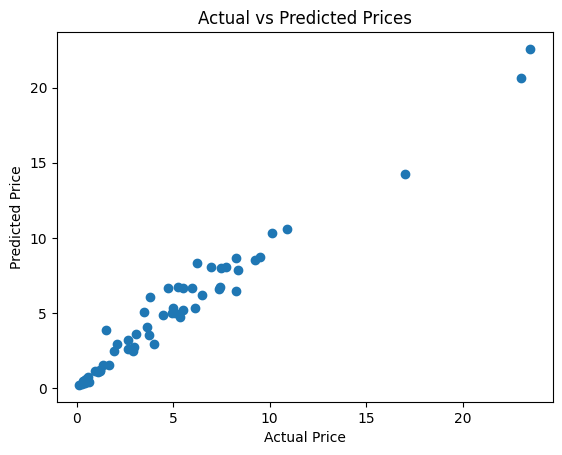

In [53]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [54]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Present_Price    0.864421
Car_Age          0.054262
Driven_kms       0.032467
Car_Name         0.029342
transmission     0.007627
Transmission     0.006526
Selling_type     0.002290
Owner            0.001691
Fuel_Type        0.001374
dtype: float64


In [55]:
print(X.columns)

Index(['Car_Name', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type',
       'Transmission', 'Owner', 'transmission', 'Car_Age'],
      dtype='object')


In [70]:
sample_car =pd.DataFrame([[15,5.59,27000,1,0,1,0,1,10]],columns=X.columns)


In [71]:
print(model.predict(sample_car))

[3.7605]
